In [34]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
import requests
import os
import time
from dbfread import DBF
import pandas as pd
import libarchive
import dash
from dash import dcc, html, dash_table
from dash.dependencies import Input, Output, State, ALL
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from scipy.signal import periodogram
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

## Загрузка и распаковка файлов

In [35]:
start_date = datetime(2019, 1, 1)   # Начальная дата
end_date = datetime(2022, 2, 1)    # Конечная дата
base_url = "https://cbr.ru/vfs/credit/forms/101-{date}.rar"
download_dir = "cbr_files"          # Папка для сохранения
delay = 1                           # Задержка между запросами (в секундах)

os.makedirs(download_dir, exist_ok=True)

current_date = start_date
downloaded = 0
skipped = 0

print(f"Начинаем загрузку файлов с {start_date.strftime('%Y-%m-%d')} по {end_date.strftime('%Y-%m-%d')}")

while current_date <= end_date:
    date_str = current_date.strftime("%Y%m%d")
    file_url = base_url.format(date=date_str)
    file_name = os.path.join(download_dir, f"101-{date_str}.rar")
    
    
    try:
        response = requests.get(file_url, stream=True, timeout=30)
        
        if response.status_code == 200:
            with open(file_name, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            downloaded += 1
            print(f"Успешно скачан: {file_name}")
        else:
            skipped += 1
            print(f"Файл не найден: {file_url}")
            
    except Exception as e:
        print(f"Ошибка при загрузке {file_url}: {str(e)}")
        skipped += 1
    
    # Переходим к следующему месяцу
    current_date += relativedelta(months=1)
    time.sleep(delay)  

print(f"\nЗагрузка завершена! Успешно: {downloaded}, Пропущено: {skipped}")

Начинаем загрузку файлов с 2019-01-01 по 2022-02-01
Успешно скачан: cbr_files\101-20190101.rar
Успешно скачан: cbr_files\101-20190201.rar
Успешно скачан: cbr_files\101-20190301.rar
Успешно скачан: cbr_files\101-20190401.rar
Успешно скачан: cbr_files\101-20190501.rar
Успешно скачан: cbr_files\101-20190601.rar
Успешно скачан: cbr_files\101-20190701.rar
Успешно скачан: cbr_files\101-20190801.rar
Успешно скачан: cbr_files\101-20190901.rar
Успешно скачан: cbr_files\101-20191001.rar
Успешно скачан: cbr_files\101-20191101.rar
Успешно скачан: cbr_files\101-20191201.rar
Успешно скачан: cbr_files\101-20200101.rar
Успешно скачан: cbr_files\101-20200201.rar
Успешно скачан: cbr_files\101-20200301.rar
Успешно скачан: cbr_files\101-20200401.rar
Успешно скачан: cbr_files\101-20200501.rar
Успешно скачан: cbr_files\101-20200601.rar
Успешно скачан: cbr_files\101-20200701.rar
Успешно скачан: cbr_files\101-20200801.rar
Успешно скачан: cbr_files\101-20200901.rar
Успешно скачан: cbr_files\101-20201001.rar
Ус

In [36]:
archive_dir = 'cbr_files'          # Папка с архивами
temp_extract_dir = 'temp_extract'  # Временная папка для распаковки
output_file = 'combined_data.parquet' # Итоговый файл с данными
output_file_meta = 'combined_data_meta.parquet' # Итоговый файл с наименованиями организаций


os.makedirs(temp_extract_dir, exist_ok=True)

#Функция распаковки архива
def extract_with_libarchive(archive_path, output_dir):
    try:
        with libarchive.file_reader(archive_path) as archive:
            for entry in archive:
                print(f"Распаковка: {entry.pathname}")
                with open(os.path.join(output_dir, entry.pathname), "wb") as f:
                    for block in entry.get_blocks():
                        f.write(block)
        return True
    except Exception as e:
        print(f"Ошибка: {e}")
        return False
    
# Функция для обработки одного архива
def process_archive(archive_path):
    # Извлекаем дату из имени файла
    date_str = os.path.basename(archive_path).split('-')[1].split('.')[0]
    report_date = datetime.strptime(date_str, '%Y%m%d')
          
    extract_with_libarchive(archive_path, temp_extract_dir)
    
    report_date = report_date - relativedelta(months=1)
    
    # Ищем файл с данными 
    dbf_pattern = report_date.strftime('%m%YB1.dbf').lower()
    dbf_files = [f for f in os.listdir(temp_extract_dir) if f.lower() == dbf_pattern]
    
    dbf_meta_pattern = report_date.strftime('%m%YN1.dbf').lower()
    dbf_meta_files = [f for f in os.listdir(temp_extract_dir) if f.lower() == dbf_meta_pattern]
    
    if not dbf_files:
        print(f"Файл {dbf_pattern} не найден в архиве {archive_path}")
        return None
    
    # Читаем DBF файл
    dbf_path = os.path.join(temp_extract_dir, dbf_files[0])
    table = DBF(dbf_path, encoding='cp866')  # Кодировка для DOS
    
    dbf_meta_path = os.path.join(temp_extract_dir, dbf_meta_files[0])
    table_meta = DBF(dbf_meta_path, encoding='cp866')  # Кодировка для DOS

    data = []
    for record in table:
        if record.get('IITG') is not None:  
            data.append({
                'REGN': record['REGN'],
                'DATE': report_date,
                'IITG': record['IITG']
            })
            
    data_meta = []
    for record in table_meta:
        if record.get('NAME_B') is not None:
            data_meta.append({
                'REGN': record['REGN'],
                'DATE': report_date,
                'NAME_B': record['NAME_B']
            })

    # Удаляем распакованные файлы
    for f in os.listdir(temp_extract_dir):
        os.remove(os.path.join(temp_extract_dir, f))
   
    return pd.DataFrame(data), pd.DataFrame(data_meta)

# Основной цикл обработки
all_data = pd.DataFrame()
all_data_meta = pd.DataFrame()

for archive_name in os.listdir(archive_dir):
    if archive_name.endswith('.rar'):
        archive_path = os.path.join(archive_dir, archive_name)
        print(f"Обработка: {archive_name}")
        
        try:
            df, df_meta = process_archive(archive_path)
            if df is not None:
                all_data = pd.concat([all_data, df], ignore_index=True)
            if df_meta is not None:
                all_data_meta = pd.concat([all_data_meta, df_meta], ignore_index=True)    
        except Exception as e:
            print(f"Ошибка обработки архива {archive_name}: {str(e)}")


pivot_df = all_data.pivot_table(
    index='DATE', 
    columns='REGN', 
    values='IITG',
    aggfunc='sum'
) 

pivot_df_meta = all_data_meta.pivot_table(
    index='DATE', 
    columns='REGN', 
    values='NAME_B',
    aggfunc='first'
)


pivot_df.to_parquet(output_file)
pivot_df_meta.to_parquet(output_file_meta)

print(f"Данные сохранены в {output_file}")

Обработка: 101-20190101.rar
Распаковка: NAMES.DBF
Распаковка: 122018B1.DBF
Распаковка: 122018N1.DBF
Обработка: 101-20190201.rar
Распаковка: NAMES.DBF
Распаковка: 012019B1.DBF
Распаковка: 012019N1.DBF
Обработка: 101-20190301.rar
Распаковка: 022019B1.DBF
Распаковка: 022019N1.DBF
Распаковка: NAMES.DBF
Обработка: 101-20190401.rar
Распаковка: 032019N1.DBF
Распаковка: NAMES.DBF
Распаковка: 032019B1.DBF
Обработка: 101-20190501.rar
Распаковка: NAMES.DBF
Распаковка: 042019B1.DBF
Распаковка: 042019N1.DBF
Обработка: 101-20190601.rar
Распаковка: NAMES.DBF
Распаковка: 052019B1.DBF
Распаковка: 052019N1.DBF
Обработка: 101-20190701.rar
Распаковка: 062019N1.DBF
Распаковка: NAMES.DBF
Распаковка: 062019B1.DBF
Обработка: 101-20190801.rar
Распаковка: 072019B1.DBF
Распаковка: 072019N1.DBF
Распаковка: NAMES.DBF
Обработка: 101-20190901.rar
Распаковка: NAMES.DBF
Распаковка: 082019B1.DBF
Распаковка: 082019N1.DBF
Обработка: 101-20191001.rar
Распаковка: 092019N1.DBF
Распаковка: NAMES.DBF
Распаковка: 092019B1.DBF


## Визуализация исходных данных

In [37]:
# обработка данных по наименованиям организаций, выбор актуального наименования

df_reset = pivot_df_meta.reset_index()

melted = df_reset.melt(id_vars='DATE', var_name='REGN', value_name='NAME_B')
melted = melted.dropna(subset=['NAME_B'])
    
latest_names = melted.sort_values('DATE').groupby('REGN').last().reset_index()
    
pivot_df_meta_last = latest_names[['REGN', 'NAME_B']]

pivot_df_meta_last.head()

,REGN,NAME_B
0,1,АО ЮниКредит Банк
1,2,"АО ""КАБ ""Викинг"""
2,21,"ООО ""Примтеркомбанк"""
3,23,АО Банк АВБ
4,52,"ПАО ""Энергомашбанк"""


In [38]:
df = pd.read_parquet('combined_data.parquet')
df = df.reset_index().melt(id_vars='DATE', var_name='REGN', value_name='IITG')

df = pd.merge(df, pivot_df_meta_last, on='REGN', how='left')

# полное имя для отображения
df['FULL_NAME'] = df['REGN'].astype(str) + ' - ' + df['NAME_B'].fillna('Неизвестная организация')

app = dash.Dash(__name__)
app.layout = html.Div([
    html.H1("Анализ исходящих остатков кредитных организаций", 
           style={'textAlign': 'center'}),
    
    html.Div([
        html.Div([
            html.Label("Выберите временной диапазон:"),
            dcc.DatePickerRange(
                id='date-range',
                min_date_allowed=df['DATE'].min(),
                max_date_allowed=df['DATE'].max(),
                start_date=df['DATE'].min(),
                end_date=df['DATE'].max()
            )
        ], style={'width': '50%', 'display': 'inline-block', 'minHeight': '30px'}),


     html.Div([
         html.Button("Выбрать все", 
                     id="select-all", 
                     n_clicks=0,
                     style={'marginRight': '10px'}),
         html.Button("Снять все", 
                     id="deselect-all", 
                     n_clicks=0)
        ], style={'width': '40%', 'display': 'inline-block', 'verticalAlign': 'top'})
    ], style={'margin': '20px 0'}),
    
    html.Div([
        dcc.Dropdown(
            id='org-dropdown',
            options=[
                {'label': name, 'value': regn} 
                for regn, name in zip(df['REGN'], df['FULL_NAME'])
            ],
            multi=True,
            value=[],
            style={'width': '100%', 'minHeight': '50px'}
        )
    ], style={'margin': '20px 0'}),
    
    dcc.Graph(id='time-series-chart'),
    
    html.Div([
        html.H3("Статистика по выбранным организациям"),
        dash_table.DataTable(
            id='stats-table',
            columns=[
                {'name': 'Организация', 'id': 'FULL_NAME'},
                {'name': 'Среднее значение', 'id': 'mean'},
                {'name': 'Медиана', 'id': 'median'},
                {'name': 'Дисперсия', 'id': 'var'},
                {'name': 'Стандартное отклонение', 'id': 'std'}
            ],
            style_table={'overflowX': 'auto'},
            style_cell={
                'minWidth': '100px', 
                'maxWidth': '300px',
                'whiteSpace': 'normal'
            }
        )
    ], style={'margin': '20px 0'})
])

@app.callback(
    Output('org-dropdown', 'options'),
    Input('org-dropdown', 'value')
)
def update_dropdown_options(search_query):
    filtered = df['FULL_NAME'].unique()
    return [{'label': name, 'value': regn} 
           for regn, name in zip(df['REGN'].unique(), df['FULL_NAME'].unique()) 
           if name in filtered]

@app.callback(
    Output('org-dropdown', 'value'),
    [Input('select-all', 'n_clicks'),
     Input('deselect-all', 'n_clicks')],
    [State('org-dropdown', 'options')]
)
def update_selection(select_clicks, deselect_clicks, options):
    ctx = dash.callback_context
    if not ctx.triggered:
        return []
    button_id = ctx.triggered[0]['prop_id'].split('.')[0]
    
    if button_id == 'select-all':
        return [option['value'] for option in options]
    elif button_id == 'deselect-all':
        return []
    return []

@app.callback(
    [Output('time-series-chart', 'figure'),
     Output('stats-table', 'data')],
    [Input('date-range', 'start_date'),
     Input('date-range', 'end_date'),
     Input('org-dropdown', 'value')]
)
def update_chart(start_date, end_date, selected_regn):
    filtered_df = df[
        (df['DATE'] >= start_date) & 
        (df['DATE'] <= end_date) & 
        (df['REGN'].isin(selected_regn))
    ]
    
    # Статистика
    stats = []
    if not filtered_df.empty:
        stats_df = filtered_df.groupby('FULL_NAME').agg({
            'IITG': ['mean', 'median', 'var', 'std']
        }).reset_index()
        stats_df.columns = ['FULL_NAME', 'mean', 'median', 'var', 'std']
        stats = stats_df.to_dict('records')
    
    # График
    fig = px.line(
        filtered_df,
        x='DATE',
        y='IITG',
        color='FULL_NAME',
        labels={'IITG': 'Исходящие остатки, тыс. руб.', 'DATE': 'Дата'},
        title='Динамика исходящих остатков',
        hover_data={'FULL_NAME': True, 'REGN': True}
    )
    
    fig.update_layout(
        hovermode='x unified',
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        height=400
    )
    
    return fig, stats

app.run_server(debug=True, port=8080)

## Предобработка временных рядов

In [39]:
def preprocess_financial_data(file_path='combined_data.parquet', 
                             imputation_method='auto',
                             smoothing_method='ema',
                             window_size=12,
                             knn_neighbors=5):
    """
    file_path (str): путь к файлу данных
    imputation_method (str): метод заполнения пропусков ('linear', 'time', 'knn', 'auto')
    smoothing_method (str): метод сглаживания ('ma' - скользящее среднее, 'ema' - экспоненциальное сглаживание)
    window_size (int): размер окна для сглаживания
    knn_neighbors (int): количество соседей для KNN
    """
    

    df = pd.read_parquet(file_path)  
    df = df.reset_index().melt(id_vars='DATE', var_name='REGN', value_name='IITG')
    
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.set_index(['REGN', 'DATE']).sort_index()
 

    processed_dfs = []
    
    for regn in tqdm(df.index.get_level_values('REGN').unique(), desc='Processing'):

        ts = df.xs(regn, level='REGN')['IITG']

        full_date_range = pd.date_range(start=ts.index.min(),
                                       end=ts.index.max(),
                                       freq='MS')
        ts = ts.reindex(full_date_range)

        #заполнение пропусков
        if ts.isna().sum() > 0:
            if imputation_method == 'auto':
                na_ratio = ts.isna().sum() / len(ts)
                if na_ratio < 0.1:
                    ts = ts.interpolate(method='time')
                else:
                    ts = _knn_impute(ts, knn_neighbors)
                    
            else:
                ts = _apply_imputation(ts, imputation_method, 
                                      knn_neighbors)
        
        #сглаживание данных
        ts_smooth = _apply_smoothing(ts, smoothing_method, window_size)
        

        processed_df = pd.DataFrame({
            'IITG': ts_smooth
        })
        processed_df['REGN'] = regn
        processed_dfs.append(processed_df)
    
    #сохранение данных
    final_df = pd.concat(processed_dfs)
    final_df.index.names = ['DATE']
    final_df
    final_df = final_df.pivot_table(
        index='DATE', 
        columns='REGN', 
        values='IITG'
    ) 

    
    final_df.to_parquet(file_path)
    print(f"Данные успешно обработаны и сохранены в {file_path}")
    
    return final_df

def _apply_imputation(ts, method, knn_neighbors):
    if method == 'linear':
        return ts.interpolate(method='linear')
    elif method == 'time':
        return ts.interpolate(method='time')
    elif method == 'knn':
        return _knn_impute(ts, knn_neighbors)
    else:
        raise ValueError("Неподдерживаемый метод импутации")

def _knn_impute(ts, neighbors):
    df = pd.DataFrame({
        'value': ts,
        'month': ts.index.month,
        'year': ts.index.year
    })
    

    imputer = KNNImputer(n_neighbors=neighbors)
    imputed_data = imputer.fit_transform(df)
                                         

    df_imputed = pd.DataFrame(imputed_data, columns=df.columns, index=df.index)
    return df_imputed['value']

def _apply_smoothing(ts, method, window_size):
    if method == 'ma':
        return ts.rolling(window=window_size, center=True).mean()
    elif method == 'ema':
        return ts.ewm(span=window_size, adjust=False).mean()
    else:
        raise ValueError("Неподдерживаемый метод сглаживания")

In [40]:
preprocess_financial_data(
    imputation_method='auto',
    smoothing_method='ema',
    window_size=6,
    knn_neighbors=3
).head()

Processing: 100%|███████████████████████████████████████████████████████████████████| 488/488 [00:00<00:00, 601.81it/s]


Данные успешно обработаны и сохранены в combined_data.parquet


REGN,1,2,21,23,52,53,65,67,77,85,...,3530,3531,3532,3533,3535,3536,3538,3539,3540,3541
DATE,,,,,,,,,,,,,,,,,,,,,
2018-12-01,6.232043e+10,3.984896e+07,2.316475e+07,9.754956e+09,1.581449e+08,2.932888e+08,3.448076e+08,5.702510e+08,2.801051e+08,2.140660e+07,...,1823292.0,1.406247e+08,819984.0,2.452600e+06,433264.0,1.677280e+06,3.641448e+06,7.918906e+07,6.075782e+07,2015762.0
2019-01-01,6.210179e+10,3.985633e+07,2.321751e+07,9.507566e+09,1.548401e+08,2.842909e+08,3.403591e+08,5.767639e+08,2.792177e+08,2.151061e+07,...,1823292.0,1.344718e+08,819984.0,2.468621e+06,433264.0,1.570693e+06,3.578568e+06,7.815318e+07,6.195084e+07,2015762.0
2019-02-01,6.222912e+10,3.607324e+07,2.225139e+07,9.336146e+09,1.514625e+08,2.762197e+08,3.327478e+08,5.647225e+08,2.686677e+08,2.135206e+07,...,1823292.0,1.463979e+08,819984.0,2.213388e+06,433264.0,1.537340e+06,3.367346e+06,7.741327e+07,6.280300e+07,2015762.0
2019-03-01,6.098680e+10,3.365848e+07,2.163048e+07,9.292641e+09,1.505457e+08,2.675858e+08,3.238185e+08,5.548179e+08,2.628854e+08,2.178740e+07,...,1823292.0,1.499494e+08,819984.0,2.046059e+06,433264.0,1.621580e+06,3.059544e+06,8.754270e+07,6.267931e+07,2015762.0
2019-04-01,5.885644e+10,3.211998e+07,2.091963e+07,9.261567e+09,1.471919e+08,2.628173e+08,3.198027e+08,5.625874e+08,2.624530e+08,2.192741e+07,...,1823292.0,1.592575e+08,819984.0,1.940767e+06,433264.0,1.663364e+06,2.574315e+06,9.955033e+07,6.079646e+07,2015762.0


## Анализ временного ряда

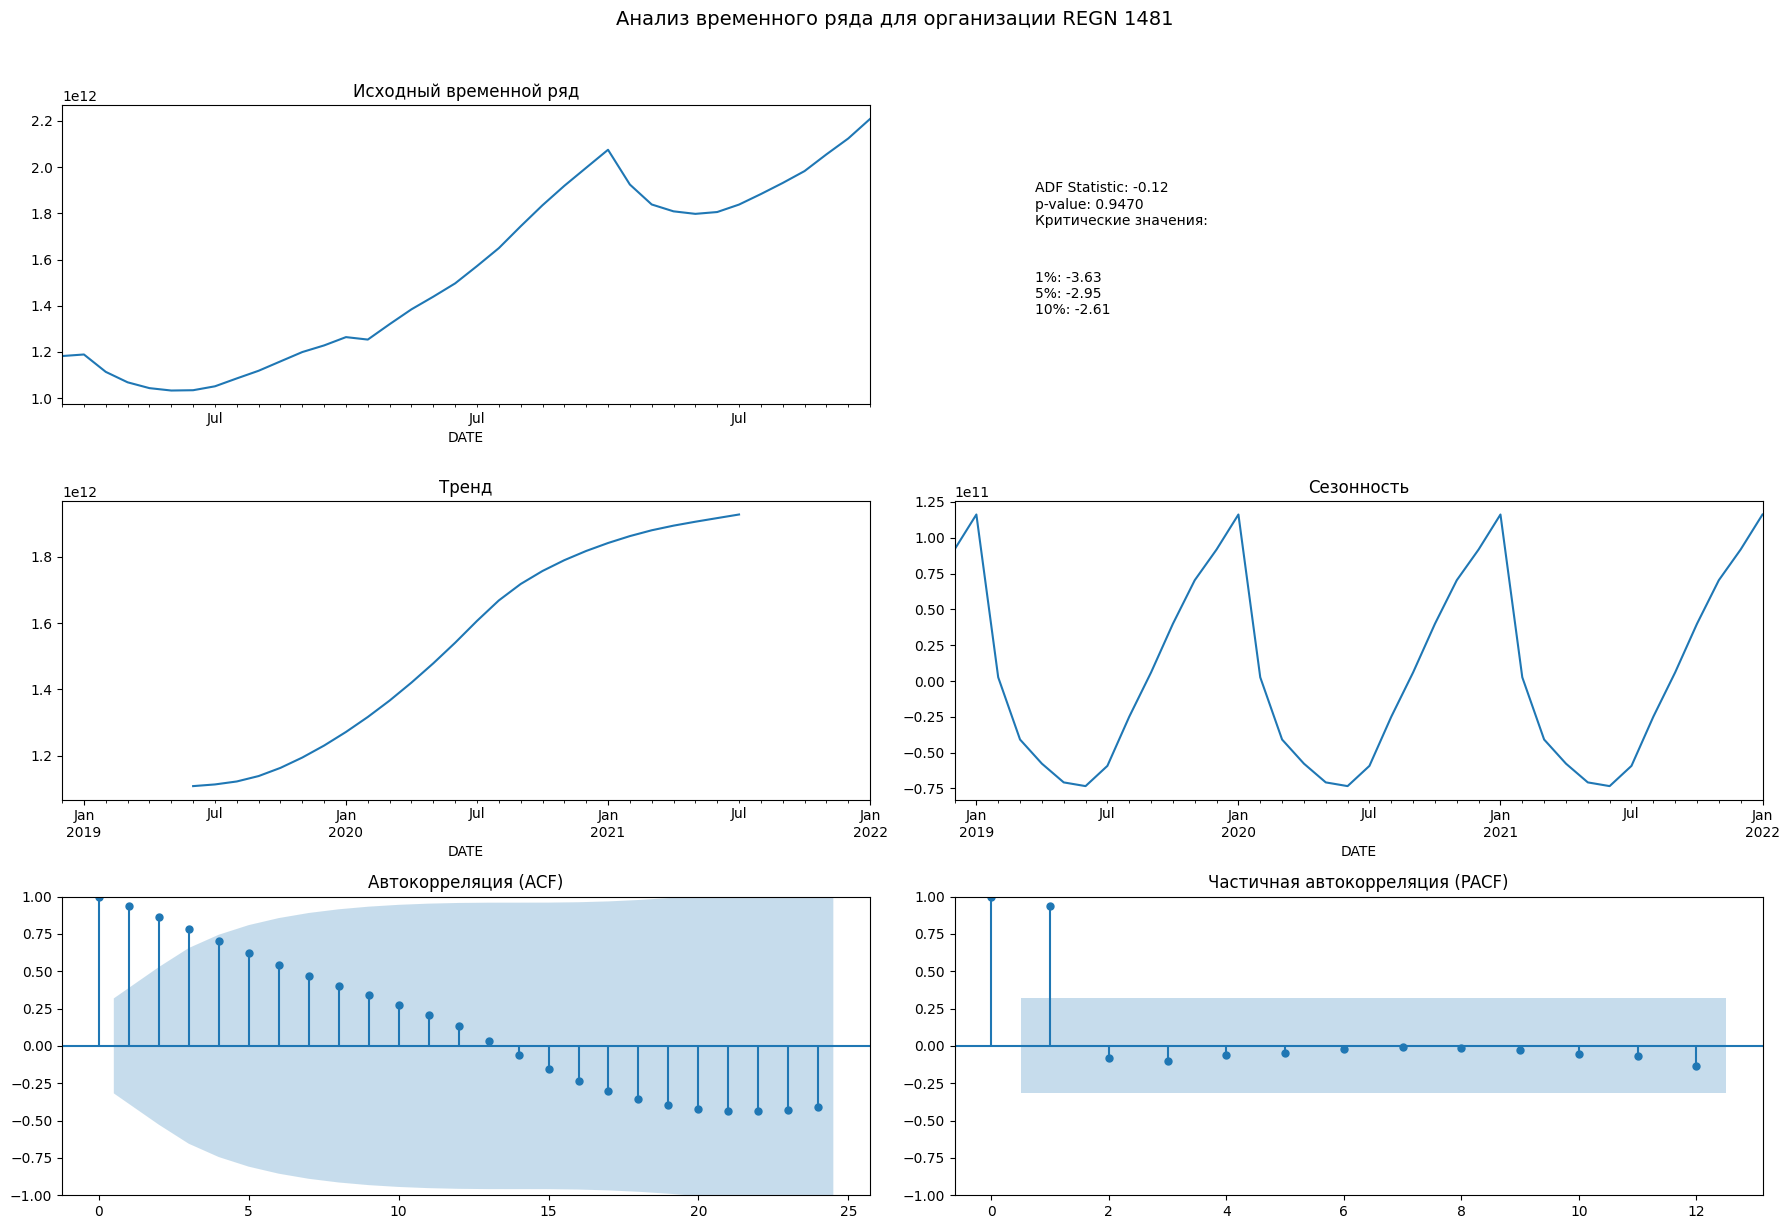

In [41]:
def analyze_time_series(regn, file_path='combined_data.parquet'):
    df = pd.read_parquet(file_path)
    df = df.reset_index().melt(id_vars='DATE', var_name='REGN', value_name='IITG')
    ts = df[df['REGN'] == regn][['DATE', 'IITG']].set_index('DATE')['IITG']
    
    if ts.empty:
        raise ValueError(f"Организация с REGN {regn} не найдена в данных")
    
    ts = ts.asfreq('MS').interpolate(method='time')
    
    plt.figure(figsize=(18, 12))
    plt.suptitle(f'Анализ временного ряда для организации REGN {regn}', y=1.02, fontsize=14)
    
    #исходный ряд и декомпозиция
    ax1 = plt.subplot(3, 2, 1)
    ts.plot(ax=ax1, title='Исходный временной ряд')
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    #тест на стационарность
    ax2 = plt.subplot(3, 2, 2)
    result = adfuller(ts)
    ax2.text(0.1, 0.6, f'ADF Statistic: {result[0]:.2f}\n'
                        f'p-value: {result[1]:.4f}\n'
                        f'Критические значения:',
             fontsize=10)
    ax2.text(0.1, 0.3, '\n'.join([f'{k}: {v:.2f}' for k, v in result[4].items()]),
             fontsize=10)
    ax2.axis('off')
    
    #декомпозиция ряда
    ax3 = plt.subplot(3, 2, 3)
    decomposition = seasonal_decompose(ts, model='additive', period=12)
    decomposition.trend.plot(ax=ax3, title='Тренд')
    
    ax4 = plt.subplot(3, 2, 4)
    decomposition.seasonal.plot(ax=ax4, title='Сезонность')
    
    #ACF и PACF
    ax5 = plt.subplot(3, 2, 5)
    plot_acf(ts, lags=24, ax=ax5)
    ax5.set_title('Автокорреляция (ACF)')
    
    ax6 = plt.subplot(3, 2, 6)
    plot_pacf(ts, lags=12, ax=ax6, method='ywm')
    ax6.set_title('Частичная автокорреляция (PACF)')
    
    plt.tight_layout()

 
    return plt.show()

# Пример использования
analyze_time_series(regn=1481)

## Поиск аномалий

In [42]:
def detect_anomalies(regn,
                     file_path='combined_data.parquet',
                     method='zscore',
                     contamination=0.05,
                     eps=None,
                     eps_auto=True,
                     z_thresh=2.5,
                     iqr_window=6,
                     plot=True,
                     verbose=True,
                     return_df=False
):

    df = pd.read_parquet(file_path)
    df = df.reset_index().melt(id_vars='DATE', var_name='REGN', value_name='IITG')
    ts = df[df['REGN'] == regn][['DATE', 'IITG']]
    if ts.empty:
        raise ValueError(f"REGN {regn} не найден")
    ts = ts.set_index('DATE').sort_index().asfreq('MS')
    ts['IITG'] = ts['IITG'].interpolate()

    # STL-декомпозиция
    stl = STL(ts['IITG'], period=12)
    res = stl.fit()
    ts['trend'] = res.trend
    ts['seasonal'] = res.seasonal
    ts['resid'] = res.resid
    ts['trend_delta'] = ts['trend'].diff()
    ts['rolling_std'] = ts['resid'].rolling(3, center=True).std()
    ts['lag1'] = ts['resid'].shift(1)
    ts['lag2'] = ts['resid'].shift(2)

    # ACF и PACF признаки
    acf_vals = acf(ts['resid'].dropna(), nlags=4)
    pacf_vals = pacf(ts['resid'].dropna(), nlags=2)
    for i in range(1, 5):
        ts[f'acf{i}'] = acf_vals[i]
    for i in range(1, 3):
        ts[f'pacf{i}'] = pacf_vals[i]

    # финальное X
    features = ['resid', 'seasonal', 'trend_delta', 'rolling_std', 'lag1', 'lag2'] + \
               [f'acf{i}' for i in range(1, 5)] + [f'pacf{i}' for i in range(1, 3)]
    X = ts[features].dropna().copy()
    ts = ts.loc[X.index]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    
    # определение n_neighbors и eps
    n_neighbors = max(5, min(20, int(len(X_scaled) * 0.1)))

    if method == 'dbscan' and (eps is None or eps_auto):
        nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_scaled)
        distances, _ = nbrs.kneighbors(X_scaled)
        k_dist = np.sort(distances[:, -1])
        eps = np.percentile(k_dist, 90)
        if verbose:
            print(f"[AUTO] eps = {eps:.4f}")

    # модели
    if method == 'lof':
        model = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
        preds = model.fit_predict(X_scaled)
        scores = -model.negative_outlier_factor_

    elif method == 'svm':
        model = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
        model.fit(X_scaled)
        preds = model.predict(X_scaled)
        scores = -model.decision_function(X_scaled)

    elif method == 'dbscan':
        model = DBSCAN(eps=eps, min_samples=n_neighbors)
        preds = model.fit_predict(X_scaled)
        preds = np.where(preds == -1, -1, 1)
        nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X_scaled)
        distances, _ = nbrs.kneighbors(X_scaled)
        scores = distances[:, -1]

    elif method == 'zscore':
        z = (X['resid'] - X['resid'].mean()) / X['resid'].std()
        preds = np.where(np.abs(z) > z_thresh, -1, 1)
        scores = np.abs(z)

    elif method == 'iforest':
        model = IsolationForest(contamination=contamination, random_state=42)
        model.fit(X_scaled)
        preds = model.predict(X_scaled)
        scores = -model.decision_function(X_scaled)

    elif method == 'moving_iqr':
        q25 = ts['resid'].rolling(iqr_window).quantile(0.25)
        q75 = ts['resid'].rolling(iqr_window).quantile(0.75)
        iqr = q75 - q25
        upper = q75 + 1.5 * iqr
        lower = q25 - 1.5 * iqr
        mask = (ts['resid'] > upper) | (ts['resid'] < lower)
        preds = np.where(mask, -1, 1)
        scores = (np.abs(ts['resid'] - ts['resid'].median()) / (iqr + 1e-6)).fillna(0).values

    else:
        raise ValueError(f"Метод {method} не поддерживается")

    ts['anomaly'] = preds == -1
    ts['score'] = (scores - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-8)

    if verbose:
        print(f"Найдено аномалий: {ts['anomaly'].sum()} методом {method}")

    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(ts.index, ts['IITG'], label='IITG', color='blue')
        plt.plot(ts.index, ts['trend'] + ts['seasonal'], label='Trend+Season', linestyle='--', color='green')
        plt.scatter(ts.index[ts['anomaly']], ts['IITG'][ts['anomaly']], color='red', s=60, label='Аномалии', marker='x')
        plt.title(f"REGN: {regn} | Метод: {method.upper()}")
        plt.xlabel("Дата")
        plt.ylabel("IITG")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ts if return_df else {
        'regn': regn,
        'method': method,
        'anomalies': ts[ts['anomaly']].index.tolist(),
        'anomaly_scores': ts.loc[ts['anomaly'], 'score'].to_dict(),
        'eps': eps if method == 'dbscan' else None,
        'n_neighbors': n_neighbors
    }


Найдено аномалий: 2 методом zscore


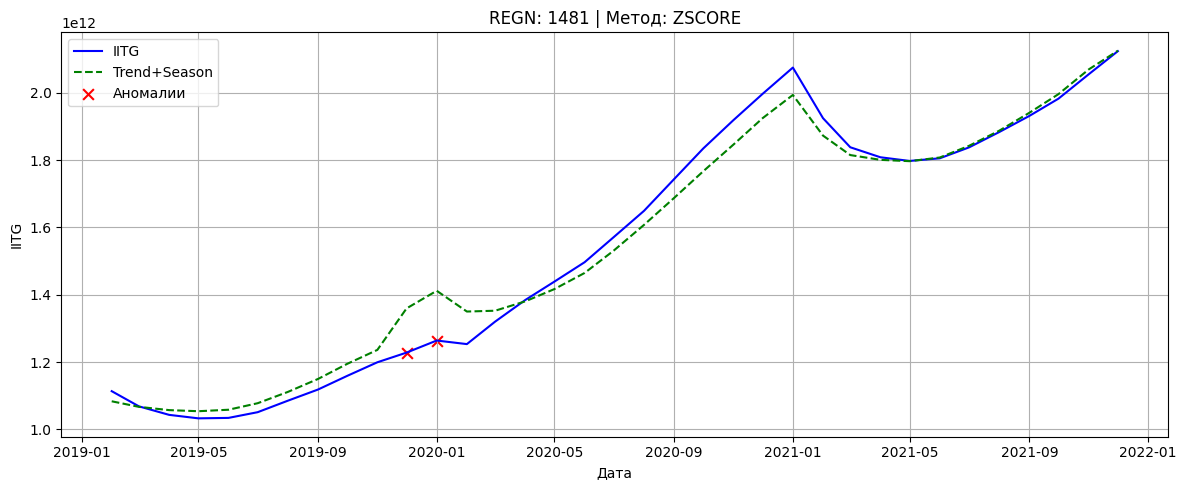

{'regn': 1481,
 'method': 'zscore',
 'anomalies': [Timestamp('2019-12-01 00:00:00'),
  Timestamp('2020-01-01 00:00:00')],
 'anomaly_scores': {Timestamp('2019-12-01 00:00:00'): 0.8865300325960636,
  Timestamp('2020-01-01 00:00:00'): 0.99999999646326},
 'eps': None,
 'n_neighbors': 5}

In [28]:
detect_anomalies(1481,method='zscore')

[AUTO] eps = 3.3043
Найдено аномалий: 2 методом dbscan


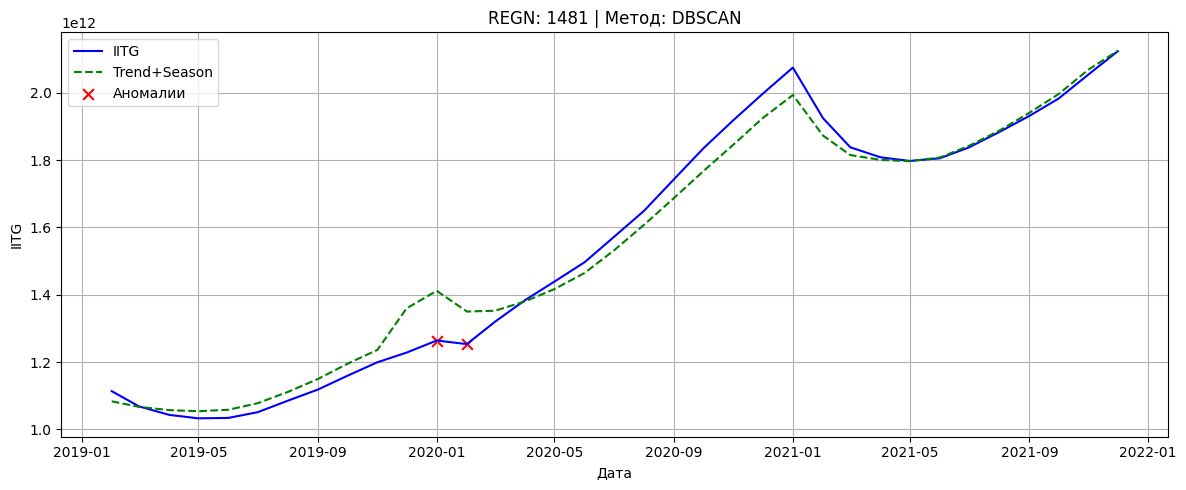

{'regn': 1481,
 'method': 'dbscan',
 'anomalies': [Timestamp('2020-01-01 00:00:00'),
  Timestamp('2020-02-01 00:00:00')],
 'anomaly_scores': {Timestamp('2020-01-01 00:00:00'): 0.9999999969894229,
  Timestamp('2020-02-01 00:00:00'): 0.8685519490644006},
 'eps': np.float64(3.3042895961545584),
 'n_neighbors': 5}

In [29]:
detect_anomalies(1481,method='dbscan')

Найдено аномалий: 2 методом iforest


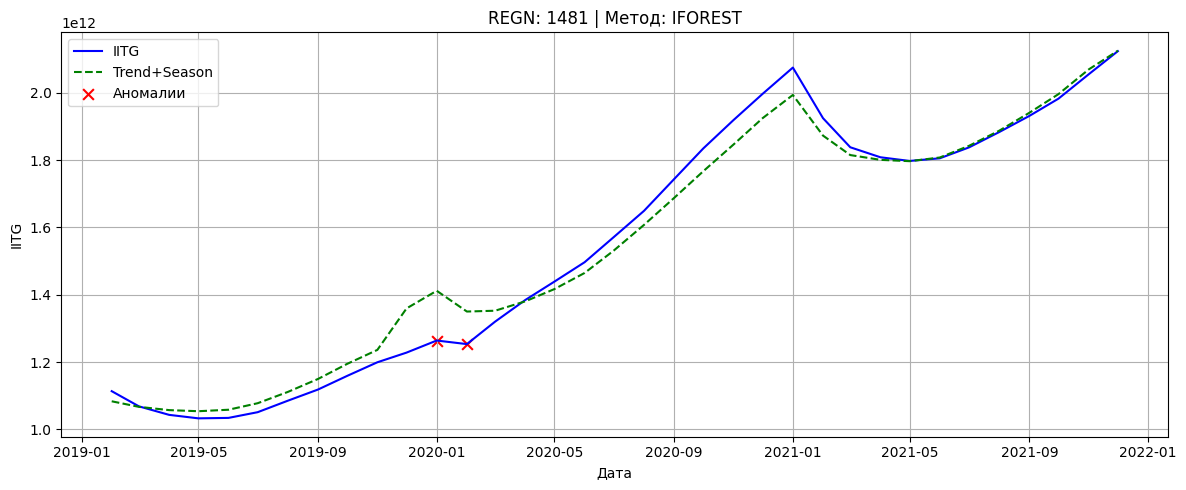

{'regn': 1481,
 'method': 'iforest',
 'anomalies': [Timestamp('2020-01-01 00:00:00'),
  Timestamp('2020-02-01 00:00:00')],
 'anomaly_scores': {Timestamp('2020-01-01 00:00:00'): 0.9598508997354014,
  Timestamp('2020-02-01 00:00:00'): 0.9999999597639999},
 'eps': None,
 'n_neighbors': 5}

In [30]:
detect_anomalies(1481,method='iforest')

Найдено аномалий: 2 методом lof


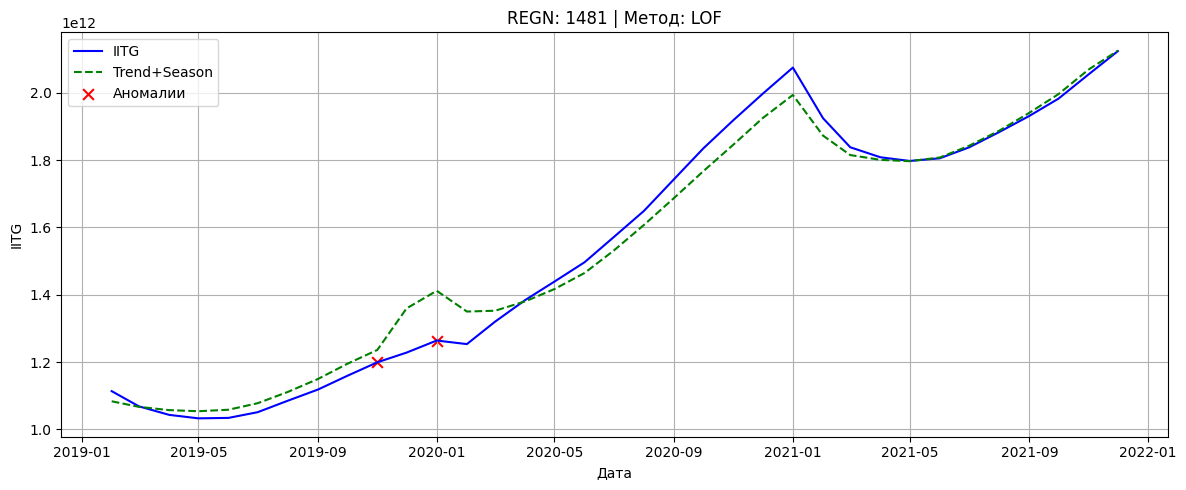

{'regn': 1481,
 'method': 'lof',
 'anomalies': [Timestamp('2019-11-01 00:00:00'),
  Timestamp('2020-01-01 00:00:00')],
 'anomaly_scores': {Timestamp('2019-11-01 00:00:00'): 0.7775109501638424,
  Timestamp('2020-01-01 00:00:00'): 0.9999999940827369},
 'eps': None,
 'n_neighbors': 5}

In [31]:
detect_anomalies(1481,method='lof')

Найдено аномалий: 6 методом svm


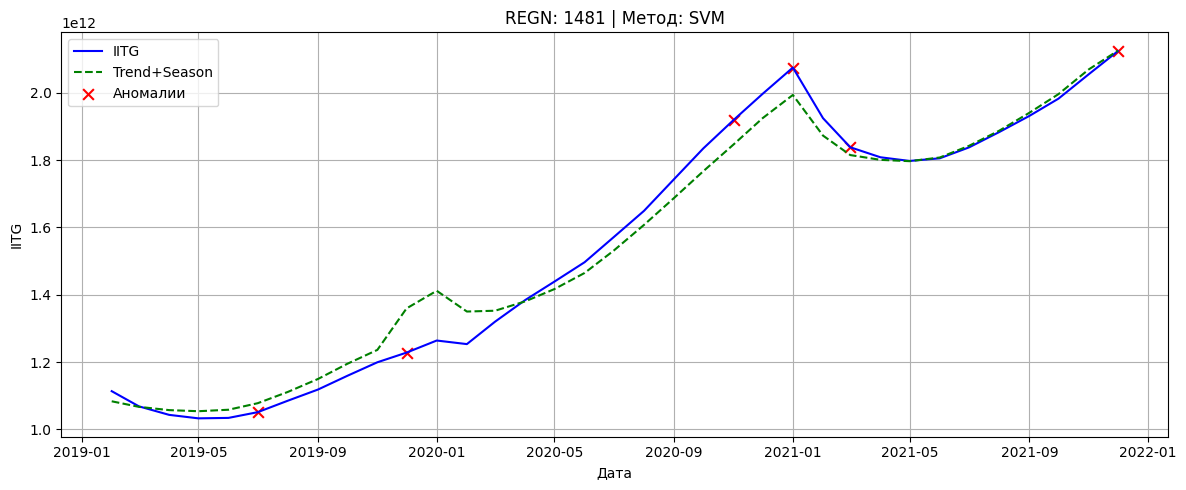

{'regn': 1481,
 'method': 'svm',
 'anomalies': [Timestamp('2019-07-01 00:00:00'),
  Timestamp('2019-12-01 00:00:00'),
  Timestamp('2020-11-01 00:00:00'),
  Timestamp('2021-01-01 00:00:00'),
  Timestamp('2021-03-01 00:00:00'),
  Timestamp('2021-12-01 00:00:00')],
 'anomaly_scores': {Timestamp('2019-07-01 00:00:00'): 0.9950496021088837,
  Timestamp('2019-12-01 00:00:00'): 0.9998559439510487,
  Timestamp('2020-11-01 00:00:00'): 0.9999998610256233,
  Timestamp('2021-01-01 00:00:00'): 0.9954422244820759,
  Timestamp('2021-03-01 00:00:00'): 0.9961245738292688,
  Timestamp('2021-12-01 00:00:00'): 0.9936483254117613},
 'eps': None,
 'n_neighbors': 5}

In [32]:
detect_anomalies(1481,method='svm')

Найдено аномалий: 2 методом moving_iqr


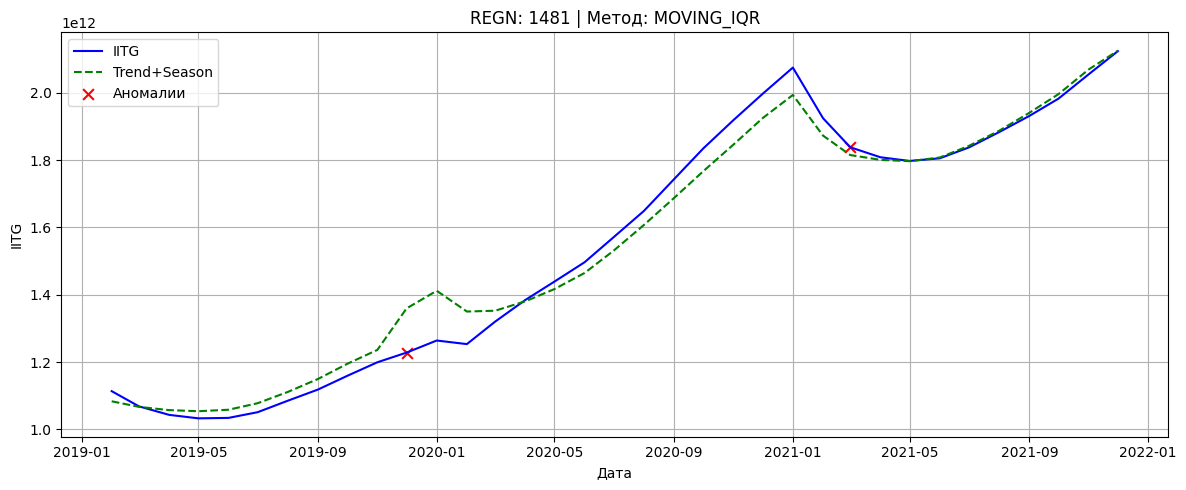

{'regn': 1481,
 'method': 'moving_iqr',
 'anomalies': [Timestamp('2019-12-01 00:00:00'),
  Timestamp('2021-03-01 00:00:00')],
 'anomaly_scores': {Timestamp('2019-12-01 00:00:00'): 0.9999999993288645,
  Timestamp('2021-03-01 00:00:00'): 0.1015933597226834},
 'eps': None,
 'n_neighbors': 5}

In [33]:
detect_anomalies(1481,method='moving_iqr')